<a href="https://colab.research.google.com/github/trumanPHYS/Physics-Data-Plots-1/blob/main/SPRINGLab10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

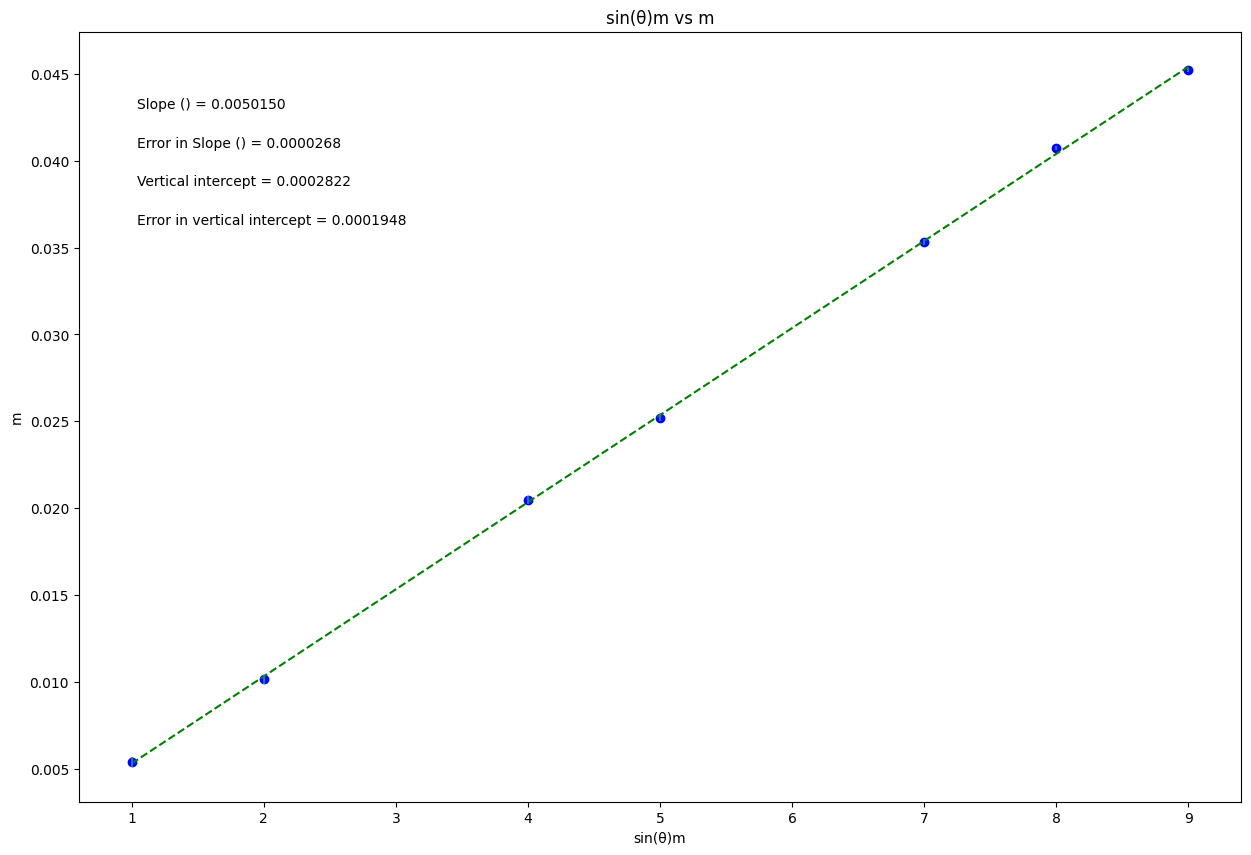

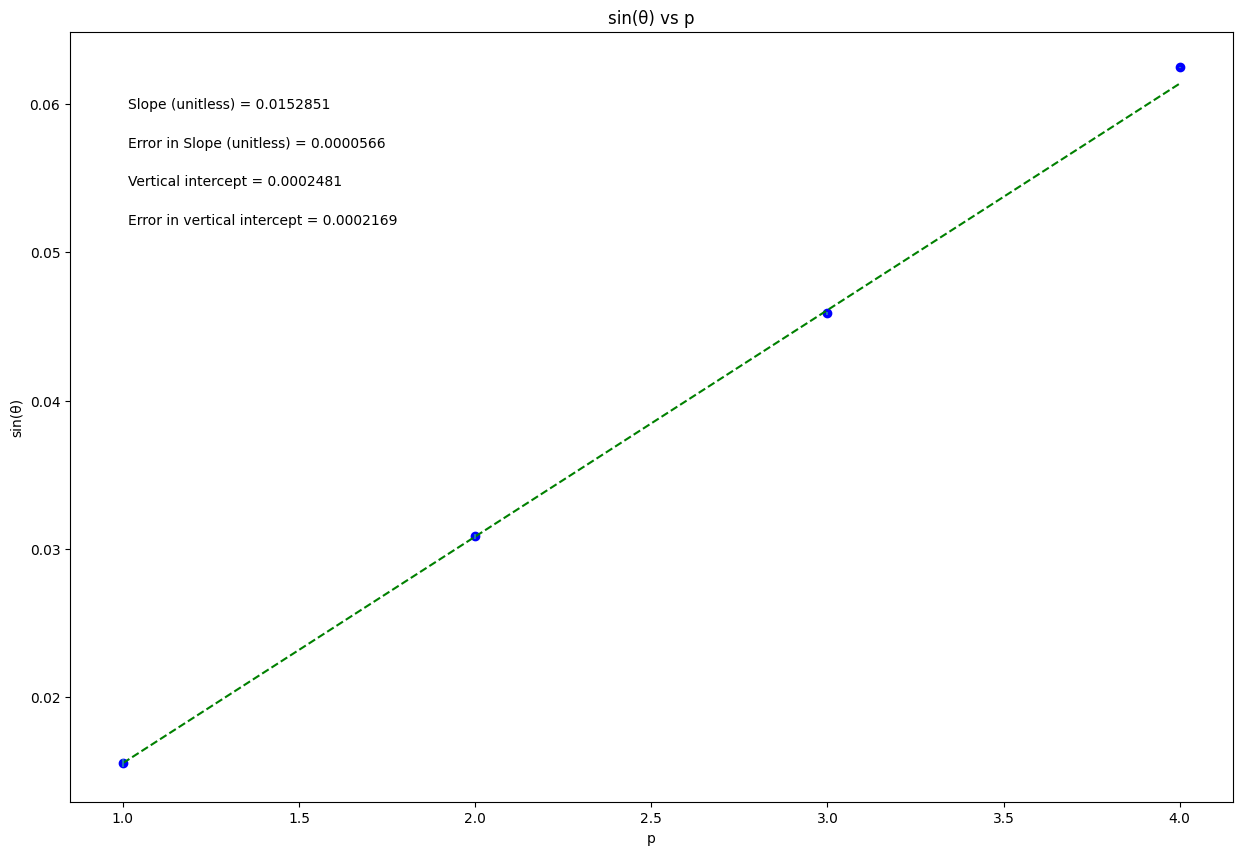

In [2]:
# PHSX 216 & 218 plotting code
# Brianna Beller
# Updated September 2023

# import packages and libraries, assign shortcut names
%matplotlib inline
from __future__ import division  # only used if running python 2
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------
# ----------UPDATE THIS SECTION!!!----------
# DATA TO BE PLOTTED

# variable names should start with a letter and must contain only letters, numbers, and underscores
xvariable_changeme = np.array([1, 2, 4, 5, 7, 8, 9])
yvariable_changeme = np.array([
    0.00540533, 0.01013461, 0.02049119,
    0.0252172, 0.03533827, 0.04073193, 0.04522395
])
err_yvariable_changeme = np.array([
    0.000293, 0.000272, 0.000225,
    0.000204, 0.000158, 0.000134, 0.000114
])

# second dataset
x2 = np.array([1, 2, 3, 4])  # p values
y2 = np.array([0.015539, 0.030841, 0.045898, 0.06249])  # sin(theta)
dy2 = np.array([0.000247, 0.000179, 0.000111, 0.0000362])  # uncertainties

# Re-assign variables
x = xvariable_changeme
y = yvariable_changeme
dy = err_yvariable_changeme

# Plot labels
plot_title = 'sin(θ)m vs m'
x_label = 'sin(θ)m'
y_label = 'm'
slope_units = ''

# Annotation placement (1–4)
annotation_placement = 2

# -----------------------------------------------------------------------
# -----DON'T NEED TO CHANGE ANYTHING BEYOND THIS POINT!!!-----

# Best fit line
b, m = np.polynomial.polynomial.polyfit(x, y, 1, w=dy)
fit = b + m * x

# Error calculations
def Delta(x, dy):
    return (sum(1/dy**2)) * (sum(x**2/dy**2)) - (sum(x/dy**2))**2

D = Delta(x, dy)
dm = np.sqrt(1/D * sum(1/dy**2))
db = np.sqrt(1/D * sum(x**2/dy**2))

# Goodness of fit
def LLSFD2(x, y, dy):
    return sum(((y - b - m * x) / dy) ** 2)

N = LLSFD2(x, y, dy)

# Annotation positioning
if annotation_placement in [2, 3]:
    xpos = 0.05
else:
    xpos = 0.75

if annotation_placement in [1, 2]:
    ypos = [.9, .85, .8, .75]
else:
    ypos = [.2, .15, .1, .05]

# -----------------------------------------------------------------------
# Plot first graph
plt.figure(figsize=(15, 10))
plt.plot(x, fit, color='green', linestyle='--')
plt.scatter(x, y, color='blue', marker='o')
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title(plot_title)
plt.errorbar(x, y, yerr=dy, fmt="none")

plt.annotate(f'Slope ({slope_units}) = {m:.7f}', (xpos, ypos[0]), xycoords='axes fraction')
plt.annotate(f'Error in Slope ({slope_units}) = {dm:.7f}', (xpos, ypos[1]), xycoords='axes fraction')
plt.annotate(f'Vertical intercept = {b:.7f}', (xpos, ypos[2]), xycoords='axes fraction')
plt.annotate(f'Error in vertical intercept = {db:.7f}', (xpos, ypos[3]), xycoords='axes fraction')

plt.show()

# ================= SECOND GRAPH =================

# Fit second dataset
b2, m2 = np.polynomial.polynomial.polyfit(x2, y2, 1, w=dy2)
fit2 = b2 + m2 * x2

# Error calculations
D2 = (sum(1/dy2**2)) * (sum(x2**2/dy2**2)) - (sum(x2/dy2**2))**2
dm2 = np.sqrt(1/D2 * sum(1/dy2**2))
db2 = np.sqrt(1/D2 * sum(x2**2/dy2**2))

# Plot second graph
plt.figure(figsize=(15, 10))
plt.plot(x2, fit2, color='green', linestyle='--')
plt.scatter(x2, y2, color='blue', marker='o')
plt.xlabel('p')
plt.ylabel('sin(θ)')
plt.title('sin(θ) vs p')
plt.errorbar(x2, y2, yerr=dy2, fmt="none")

plt.annotate(f'Slope (unitless) = {m2:.7f}', (0.05, 0.9), xycoords='axes fraction')
plt.annotate(f'Error in Slope (unitless) = {dm2:.7f}', (0.05, 0.85), xycoords='axes fraction')
plt.annotate(f'Vertical intercept = {b2:.7f}', (0.05, 0.8), xycoords='axes fraction')
plt.annotate(f'Error in vertical intercept = {db2:.7f}', (0.05, 0.75), xycoords='axes fraction')

plt.show()